In [1]:
import numpy as np
import pandas as pd

url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DCOILWTICO"
price = pd.read_csv(url)

price["observation_date"] = pd.to_datetime(price["observation_date"], errors="coerce")
price["DCOILWTICO"] = pd.to_numeric(price["DCOILWTICO"], errors="coerce")

START_DATE = "2014-01-01"

price = (
    price.rename(columns={
        "observation_date": "date",
        "DCOILWTICO": "price"
    })
    .dropna()
    .query("date >= @START_DATE")
    .query("price > 0")
    .sort_values("date")
    .reset_index(drop=True)
)

price["log_price"] = np.log(price["price"])
price["return"] = 100 * price["log_price"].diff()

df = price.dropna().copy()
print("Sample window:", df["date"].min(), "to", df["date"].max())
print("Number of return observations:", len(df))
df.head()

Sample window: 2014-01-03 00:00:00 to 2026-04-13 00:00:00
Number of return observations: 3072


,date,price,log_price,return
1,2014-01-03,93.66,4.539671,-1.567829
2,2014-01-06,93.12,4.533889,-0.578222
3,2014-01-07,93.31,4.535927,0.203830
4,2014-01-08,91.90,4.520701,-1.522625
5,2014-01-09,91.36,4.514808,-0.589328


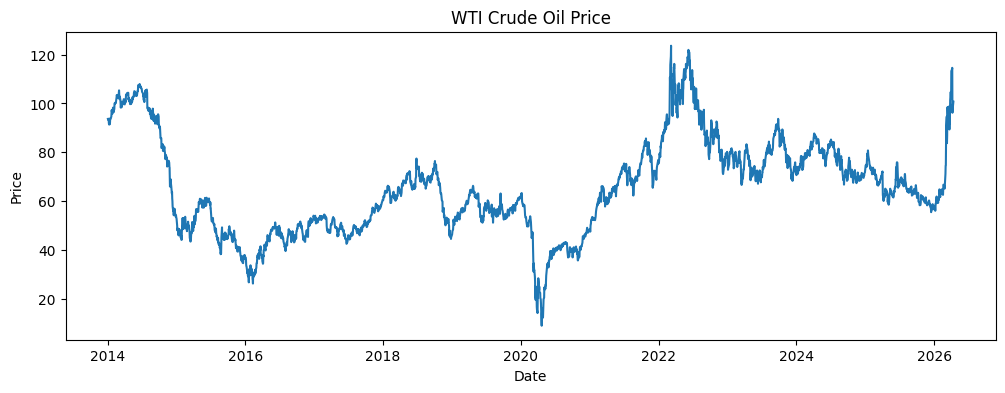

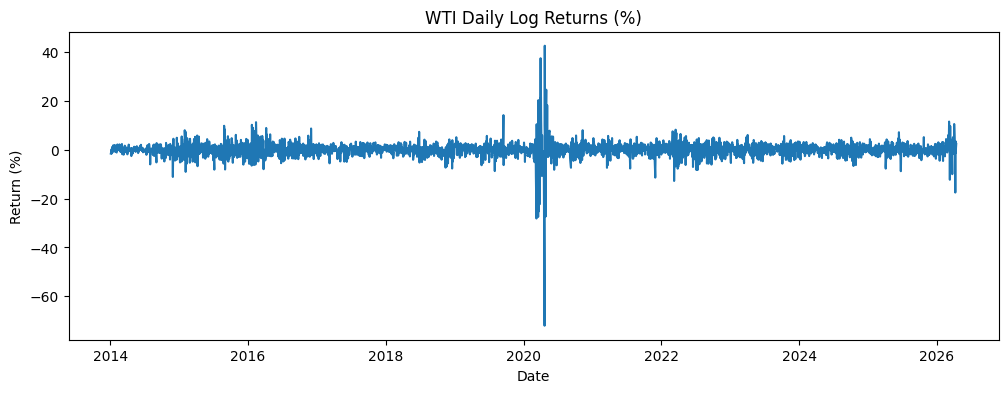

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["price"])
plt.title("WTI Crude Oil Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["return"])
plt.title("WTI Daily Log Returns (%)")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.show()

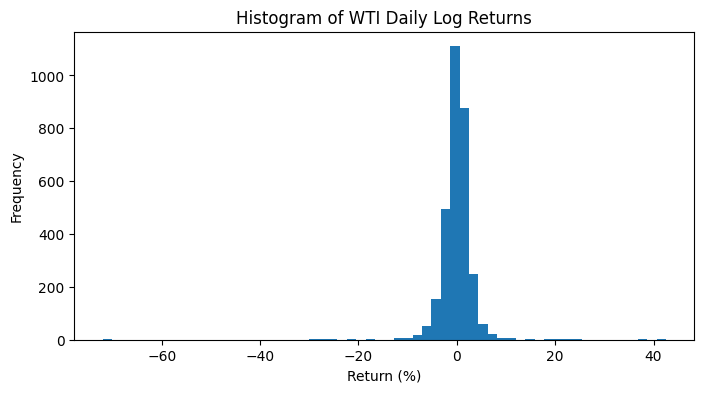

In [3]:
plt.figure(figsize=(8, 4))
plt.hist(df["return"], bins=60)
plt.title("Histogram of WTI Daily Log Returns")
plt.xlabel("Return (%)")
plt.ylabel("Frequency")
plt.show()

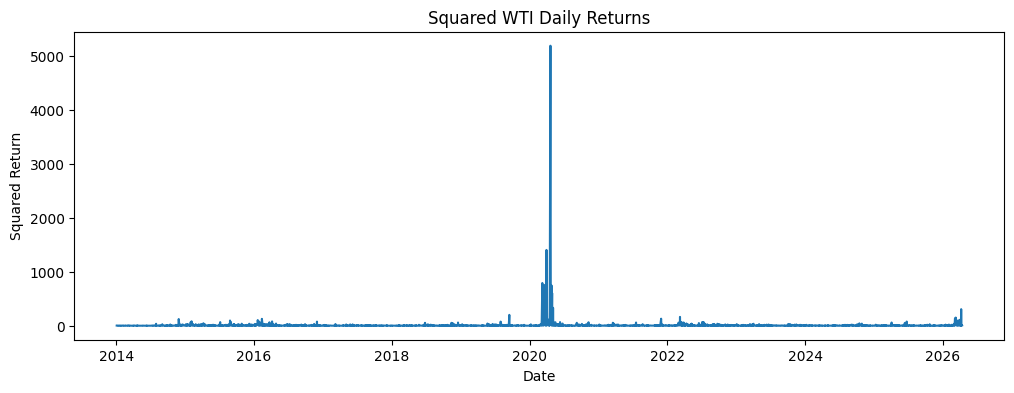

In [4]:
df["sq_return"] = df["return"] ** 2

plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["sq_return"])
plt.title("Squared WTI Daily Returns")
plt.xlabel("Date")
plt.ylabel("Squared Return")
plt.show()

<Figure size 800x400 with 0 Axes>

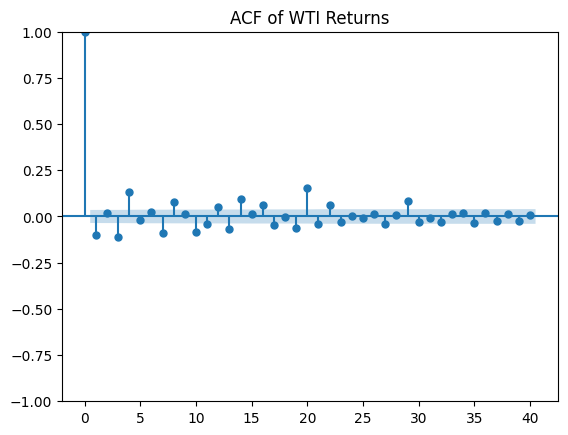

<Figure size 800x400 with 0 Axes>

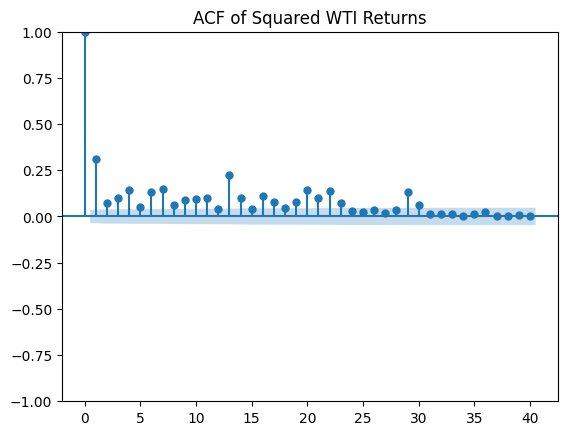

In [5]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(8, 4))
plot_acf(df["return"], lags=40)
plt.title("ACF of WTI Returns")
plt.show()

plt.figure(figsize=(8, 4))
plot_acf(df["sq_return"], lags=40)
plt.title("ACF of Squared WTI Returns")
plt.show()

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

y = df["return"]

max_p = 3
max_q = 3

aic_grid = pd.DataFrame(
    index=[f"AR({p})" for p in range(max_p + 1)],
    columns=[f"MA({q})" for q in range(max_q + 1)],
    dtype=float
)

for p in range(max_p + 1):
    for q in range(max_q + 1):
        try:
            model = ARIMA(y, order=(p, 0, q)).fit()
            aic_grid.loc[f"AR({p})", f"MA({q})"] = model.aic
        except:
            aic_grid.loc[f"AR({p})", f"MA({q})"] = np.nan

aic_grid

D:\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


,MA(0),MA(1),MA(2),MA(3)
AR(0),16014.786650,15985.460712,15987.456071,15964.587039
AR(1),15985.145398,15935.988544,15935.476090,15923.718669
AR(2),15986.843784,15935.851596,15932.206588,15924.592199
AR(3),15951.069319,15919.920680,15921.076926,15888.939346


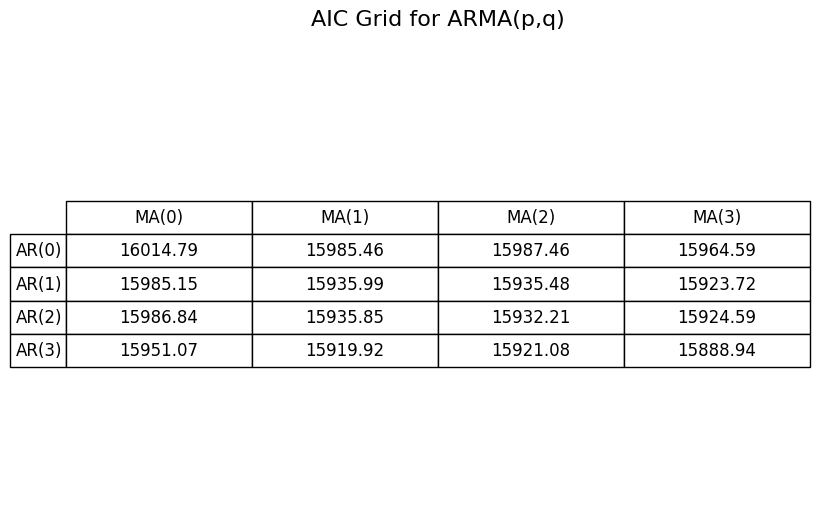

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.axis("off")

table_data = aic_grid.round(2).values
row_labels = aic_grid.index.tolist()
col_labels = aic_grid.columns.tolist()

table = ax.table(
    cellText=table_data,
    rowLabels=row_labels,
    colLabels=col_labels,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2.0)

plt.title("AIC Grid for ARMA(p,q)", fontsize=16, pad=20)
plt.show()

In [8]:
best_model = aic_grid.stack().idxmin()
best_aic = aic_grid.stack().min()

print("Best model:", best_model)
print("Best AIC:", round(best_aic, 3))

Best model: ('AR(3)', 'MA(3)')
Best AIC: 15888.939


In [9]:
from statsmodels.tsa.arima.model import ARIMA

m_31 = ARIMA(y, order=(3, 0, 1)).fit()

print("ARMA(3,1)")
print(m_31.summary())

ARMA(3,1)
                               SARIMAX Results                                
Dep. Variable:                 return   No. Observations:                 3072
Model:                 ARIMA(3, 0, 1)   Log Likelihood               -7953.960
Date:                Tue, 21 Apr 2026   AIC                          15919.921
Time:                        15:48:24   BIC                          15956.101
Sample:                             0   HQIC                         15932.919
                               - 3072                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0016      0.056      0.028      0.977      -0.108       0.111
ar.L1         -0.7120      0.030    -24.055      0.000      -0.770      -0.654
ar.L2         -0.0634      0.008     -8.09

In [10]:
# Exploratory two-step GARCH fit on ARMA(3,1) residuals
# Keep this for diagnostics / exploration, but do not use its AIC directly in
# the final model-comparison table. For the formal baseline used in the paper,
# see the AR(1)-GARCH(1,1)-t fit in the next cell.

resid_31 = m_31.resid

from arch import arch_model

garch_t = arch_model(
    resid_31,
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
).fit(disp="off")

print(garch_t.summary())


                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -6804.50
Distribution:      Standardized Student's t   AIC:                           13617.0
Method:                  Maximum Likelihood   BIC:                           13641.1
                                              No. Observations:                 3072
Date:                      Tue, Apr 21 2026   Df Residuals:                     3072
Time:                              15:48:24   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega     

In [11]:
# Formal GARCH baseline used in the final paper
# This is the model whose log-likelihood / k / AIC should be copied into the
# GARCH row of the comparison table in pomp_section.qmd.
#
# We fit the GARCH model directly to returns (not only to ARMA residuals) so
# that the reported likelihood and AIC correspond to one coherent baseline.

from arch import arch_model

y_garch = df["return"].astype(float)

garch_report = arch_model(
    y_garch,
    mean="AR",
    lags=1,
    vol="GARCH",
    p=1,
    q=1,
    dist="t",
    rescale=False
).fit(disp="off")

print("Formal baseline for report: AR(1)-GARCH(1,1)-t")
print(garch_report.summary())


Formal baseline for report: AR(1)-GARCH(1,1)-t
                              AR - GARCH Model Results                              
Dep. Variable:                       return   R-squared:                       0.002
Mean Model:                              AR   Adj. R-squared:                  0.002
Vol Model:                            GARCH   Log-Likelihood:               -6774.15
Distribution:      Standardized Student's t   AIC:                           13560.3
Method:                  Maximum Likelihood   BIC:                           13596.5
                                              No. Observations:                 3071
Date:                      Tue, Apr 21 2026   Df Residuals:                     3069
Time:                              15:48:24   Df Model:                            2
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
--------------------------------

In [12]:
# Export GARCH metrics in a form that can be pasted directly into pomp_section.qmd

import pickle

garch_ll = float(garch_report.loglikelihood)
garch_k = int(len(garch_report.params))
garch_aic = float(garch_report.aic)

garch_baseline_results = {
    "model_name": "AR(1)-GARCH(1,1)-t",
    "sample_start": str(df["date"].min().date()),
    "sample_end": str(df["date"].max().date()),
    "n_obs": int(len(df)),
    "loglik": garch_ll,
    "k": garch_k,
    "aic": garch_aic,
}

with open("garch_baseline_results.pkl", "wb") as f:
    pickle.dump(garch_baseline_results, f)

print("GARCH baseline metrics for pomp_section.qmd")
print(f"garch_ll  = {garch_ll:.2f}")
print(f"garch_k   = {garch_k}")
print(f"garch_aic = {garch_aic:.2f}")
print("\nSaved to garch_baseline_results.pkl")
garch_baseline_results


GARCH baseline metrics for pomp_section.qmd
garch_ll  = -6774.15
garch_k   = 6
garch_aic = 13560.30

Saved to garch_baseline_results.pkl


{'model_name': 'AR(1)-GARCH(1,1)-t',
 'sample_start': '2014-01-03',
 'sample_end': '2026-04-13',
 'n_obs': 3072,
 'loglik': -6774.14889573568,
 'k': 6,
 'aic': 13560.29779147136}

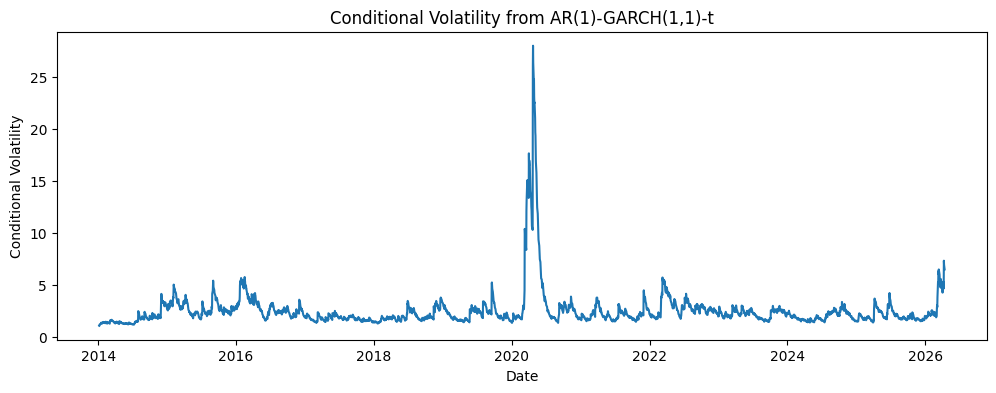

In [13]:
import matplotlib.pyplot as plt

df_garch = df.copy()
df_garch["cond_vol"] = garch_report.conditional_volatility

plt.figure(figsize=(12, 4))
plt.plot(df_garch["date"], df_garch["cond_vol"])
plt.title("Conditional Volatility from AR(1)-GARCH(1,1)-t")
plt.xlabel("Date")
plt.ylabel("Conditional Volatility")
plt.show()


In [14]:
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

y = df["return"]

ms3 = MarkovRegression(
    y,
    k_regimes=3,
    trend="c",
    switching_variance=True
)

ms3_res = ms3.fit(search_reps=10, em_iter=10)
print(ms3_res.summary())

D:\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                        Markov Switching Model Results                        
Dep. Variable:                 return   No. Observations:                 3072
Model:               MarkovRegression   Log Likelihood               -6818.444
Date:                Tue, 21 Apr 2026   AIC                          13660.889
Time:                        15:48:29   BIC                          13733.250
Sample:                             0   HQIC                         13686.886
                               - 3072                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1015      0.040      2.533      0.011       0.023       0.180
sigma2         2.2860      0.112     20.392      0.0

In [15]:
smoothed_probs = ms3_res.smoothed_marginal_probabilities
smoothed_probs.head()

,0,1,2
1,0.965507,0.034429,0.000064
2,0.979388,0.020601,0.000011
3,0.987040,0.012956,0.000004
4,0.990615,0.009383,0.000002
5,0.993943,0.006056,0.000001


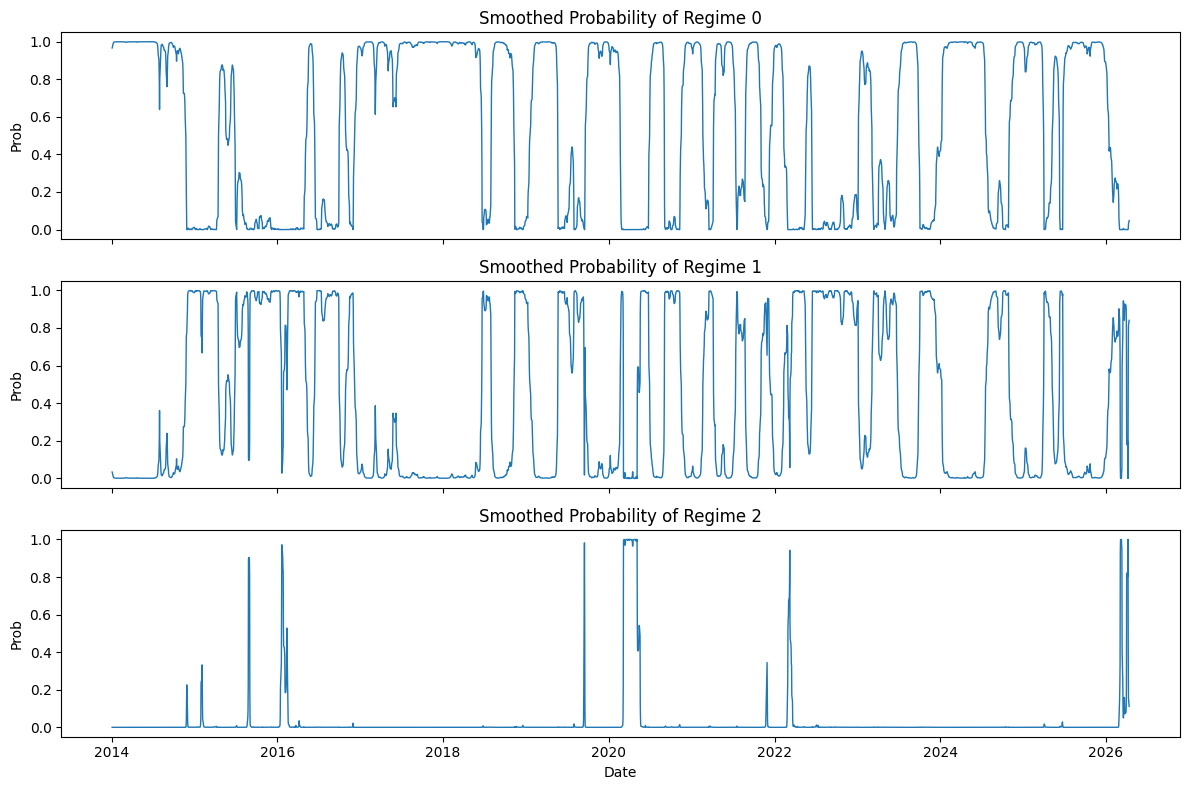

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for i in range(3):
    axes[i].plot(df["date"], smoothed_probs[i], lw=1)
    axes[i].set_title(f"Smoothed Probability of Regime {i}")
    axes[i].set_ylabel("Prob")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

In [17]:
df_ms = df.copy()
df_ms["regime"] = smoothed_probs.idxmax(axis=1)
df_ms.head()

,date,price,log_price,return,sq_return,regime
1,2014-01-03,93.66,4.539671,-1.567829,2.458087,0
2,2014-01-06,93.12,4.533889,-0.578222,0.334341,0
3,2014-01-07,93.31,4.535927,0.203830,0.041547,0
4,2014-01-08,91.90,4.520701,-1.522625,2.318388,0
5,2014-01-09,91.36,4.514808,-0.589328,0.347308,0


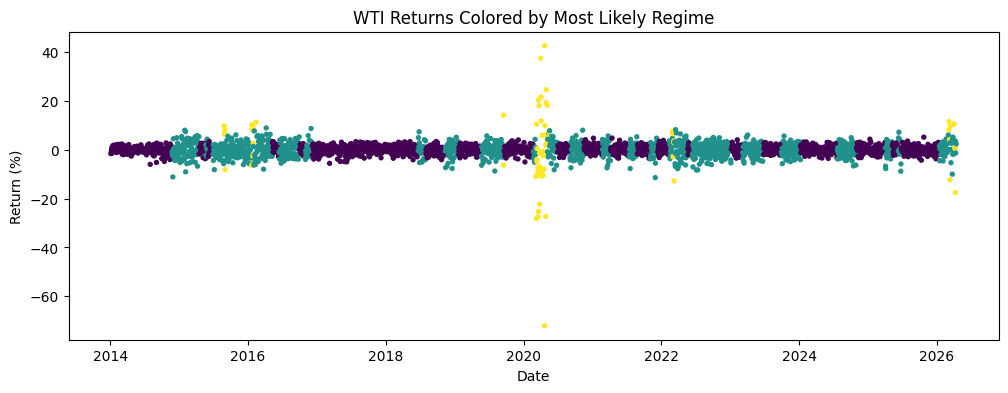

In [18]:
plt.figure(figsize=(12, 4))
plt.scatter(df_ms["date"], df_ms["return"], c=df_ms["regime"], s=8)
plt.title("WTI Returns Colored by Most Likely Regime")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.show()

In [19]:
print(ms3_res.params)

p[0->0]        0.982434
p[1->0]        0.024117
p[2->0]        0.002402
p[0->1]        0.017464
p[1->1]        0.968533
p[2->1]        0.105224
const[0]       0.101524
const[1]      -0.140649
const[2]      -0.173600
sigma2[0]      2.285964
sigma2[1]      8.578412
sigma2[2]    211.568814
dtype: float64


In [20]:
import pandas as pd
import numpy as np
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

y = df["return"]

results = []
models = {}

for k in [2, 3, 4]:
    try:
        ms = MarkovRegression(
            y,
            k_regimes=k,
            trend="c",
            switching_variance=True
        )
        res = ms.fit(search_reps=10, em_iter=10, disp=False)
        models[k] = res
        
        results.append({
            "k_regimes": k,
            "loglik": res.llf,
            "AIC": res.aic,
            "BIC": res.bic,
            "n_params": len(res.params)
        })
    except Exception as e:
        results.append({
            "k_regimes": k,
            "loglik": np.nan,
            "AIC": np.nan,
            "BIC": np.nan,
            "n_params": np.nan
        })
        print(f"{k}-state failed:", e)

state_compare = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
state_compare

D:\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\Python311\Lib\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1292: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
D:\Python311\Lib\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1292: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
D:\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization fa

,k_regimes,loglik,AIC,BIC,n_params
0,3,-6818.434008,13660.868015,13733.229025,12
1,4,-6811.126255,13662.252510,13782.854192,20
2,2,-6983.052994,13978.105988,14014.286493,6


In [21]:
for k, res in models.items():
    probs = res.smoothed_marginal_probabilities
    assigned = probs.idxmax(axis=1)
    counts = assigned.value_counts(normalize=True).sort_index()
    print(f"\n{k}-state model regime usage:")
    print(counts)


2-state model regime usage:
0    0.936849
1    0.063151
Name: proportion, dtype: float64

3-state model regime usage:
0    0.566406
1    0.409180
2    0.024414
Name: proportion, dtype: float64

4-state model regime usage:
0    0.568359
1    0.235677
2    0.162760
3    0.033203
Name: proportion, dtype: float64
